# Analyze design

In [1]:
import os
import re
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

import glob
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from bpnetlite.bpnet import BPNet, CountWrapper, ProfileWrapper, ControlWrapper, _ProfileLogitScaling
import torch
import seqpro as sp
from tangermeme.plot import plot_logo
from tangermeme.predict import predict

from scipy.spatial.distance import pdist, squareform
from sklearn.cluster import AgglomerativeClustering
import networkx as nx

The history saving thread hit an unexpected error (DatabaseError('database disk image is malformed')).History will not be written to the database.


In [2]:
def log_softmax_profile(
    y_profile,
):
    # Log softmax the predicted profile
    z = y_profile.shape
    y_profile = y_profile.reshape(y_profile.shape[0], -1)
    y_profile = torch.nn.functional.log_softmax(y_profile, dim=-1)
    y_profile = y_profile.reshape(*z)
    return y_profile

# Load genome annotation

In [3]:
# Load initial
path_gtf = "/cellar/users/aklie/opt/refdata-cellranger-arc-GRCh38-2020-A-2.0.0/genes/genes.gtf.gz"
GTF_SCHEMA = ['chrom', 'source', 'feature', 'start', 'end', 'score', 'strand', 'frame', 'attribute']
gtf = pd.read_csv(path_gtf, sep='\t', comment='#', names=GTF_SCHEMA)
gtf['gene_id'] = gtf['attribute'].str.extract('gene_id "([^"]+)"')
gtf['gene_name'] = gtf['attribute'].str.extract('gene_name "([^"]+)"')
gtf['gene_type'] = gtf['attribute'].str.extract('gene_type "([^"]+)"')

In [4]:
# Subset GTF to specified region -- anything that either starts or ends in the region
gtf_chrom = "chr5"
gtf_start = 51364731
gtf_end = 51420282
gtf_sub = gtf[(gtf['chrom'] == gtf_chrom) & (((gtf['start'] >= gtf_start) & (gtf['start'] <= gtf_end)) | ((gtf['end'] >= gtf_start) & (gtf['end'] <= gtf_end)))]

# Only get ISL1 feartures
gtf_sub = gtf_sub[gtf_sub["gene_name"] == "ISL1"].copy()
gtf_sub

,chrom,source,feature,start,end,score,strand,frame,attribute,gene_id,gene_name,gene_type
779768,chr5,HAVANA,gene,51383448,51394730,.,+,.,"gene_id ""ENSG00000016082""; gene_version ""15""; ...",ENSG00000016082,ISL1,protein_coding
779769,chr5,HAVANA,transcript,51383448,51394730,.,+,.,"gene_id ""ENSG00000016082""; gene_version ""15""; ...",ENSG00000016082,ISL1,protein_coding
779770,chr5,HAVANA,exon,51383448,51383699,.,+,.,"gene_id ""ENSG00000016082""; gene_version ""15""; ...",ENSG00000016082,ISL1,protein_coding
779771,chr5,HAVANA,CDS,51383672,51383699,.,+,0,"gene_id ""ENSG00000016082""; gene_version ""15""; ...",ENSG00000016082,ISL1,protein_coding
779772,chr5,HAVANA,start_codon,51383672,51383674,.,+,0,"gene_id ""ENSG00000016082""; gene_version ""15""; ...",ENSG00000016082,ISL1,protein_coding
779773,chr5,HAVANA,exon,51384541,51384730,.,+,.,"gene_id ""ENSG00000016082""; gene_version ""15""; ...",ENSG00000016082,ISL1,protein_coding
779774,chr5,HAVANA,CDS,51384541,51384730,.,+,2,"gene_id ""ENSG00000016082""; gene_version ""15""; ...",ENSG00000016082,ISL1,protein_coding
779775,chr5,HAVANA,exon,51387490,51387749,.,+,.,"gene_id ""ENSG00000016082""; gene_version ""15""; ...",ENSG00000016082,ISL1,protein_coding
779776,chr5,HAVANA,CDS,51387490,51387749,.,+,1,"gene_id ""ENSG00000016082""; gene_version ""15""; ...",ENSG00000016082,ISL1,protein_coding
779777,chr5,HAVANA,exon,51389646,51389932,.,+,.,"gene_id ""ENSG00000016082""; gene_version ""15""; ...",ENSG00000016082,ISL1,protein_coding


# Load design data

In [102]:
paths_designs = ["/cellar/users/aklie/projects/igvf/sc-islet-design/scratch/2025_09_05/ISL1_chr5:51392398-51392614_ISM_design_f32c795fc4", "/cellar/users/aklie/projects/igvf/sc-islet-design/scratch/2025_09_05/ISL1_chr5:51392398-51392614_Ledidi_design_85de034366"]
path_out = "/cellar/users/aklie/projects/igvf/sc-islet-design/scratch/2025_09_25"

In [103]:
# Load and concatenate all designs together
design_df = pd.concat([pd.read_csv(glob.glob(p + "/*design_*.tsv")[0], sep="\t") for p in paths_designs], ignore_index=True)
edit_df = pd.concat([pd.read_csv(glob.glob(p + "/*edits_*.tsv")[0], sep="\t") for p in paths_designs], ignore_index=True)
seqlets_df = pd.concat([pd.read_csv(glob.glob(p + "/*seqlets_*.tsv")[0], sep="\t") for p in paths_designs], ignore_index=True)

In [104]:
design_ids = set(design_df["id"])
edit_ids   = set(edit_df["id"])
seqlet_ids = set(seqlets_df["id"])

print("Designs:", len(design_ids))
print("Edits:", len(edit_ids))
print("Seqlets:", len(seqlet_ids))
print("Common:", len(design_ids & edit_ids & seqlet_ids))

Designs: 800
Edits: 756
Seqlets: 800
Common: 756


# Overview

In [105]:
y_bars = sorted(design_df["design_target_prediction"].astype(float).unique())
print(f"y_bars: {y_bars}")

y_bars: [5.87, 6.42, 7.64, 10.88]


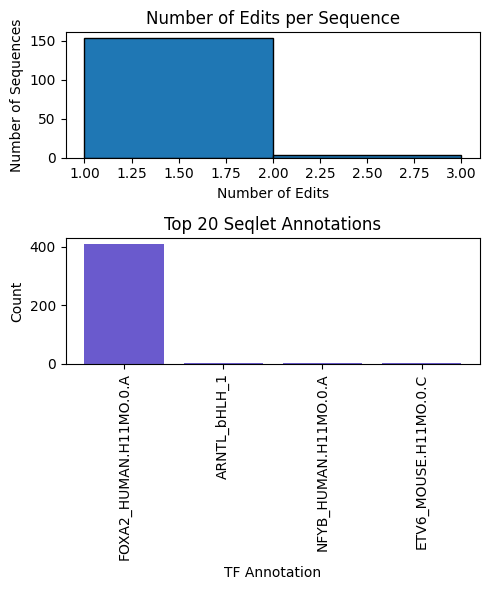

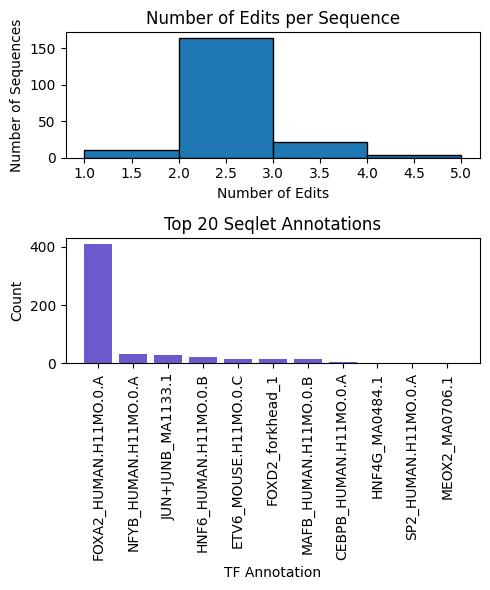

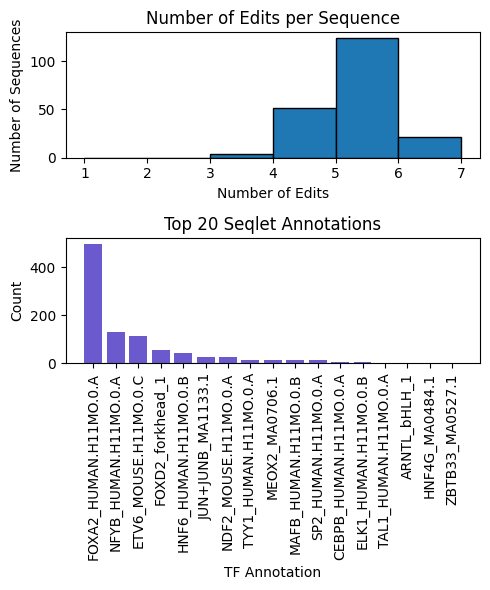

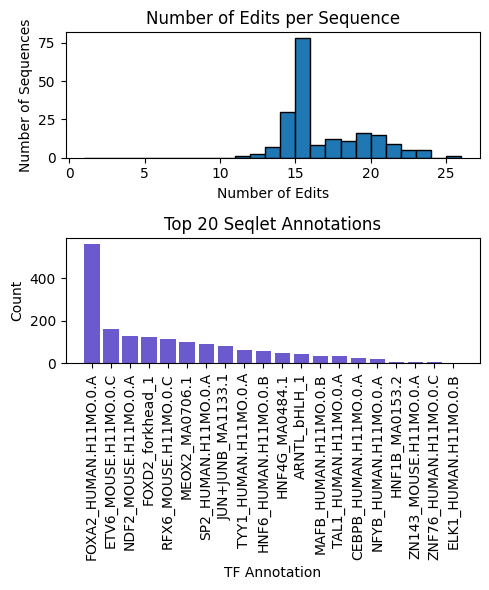

In [106]:
for y_bar in y_bars:
    
    # Filter dataframes for the current y_bar
    curr_design_df = design_df[design_df["design_target_prediction"] == y_bar]
    curr_edit_df = edit_df[edit_df["id"].isin(curr_design_df["id"])]
    curr_seqlets_df = seqlets_df[seqlets_df["id"].isin(curr_design_df["id"])]

    # Count edits per sequence
    edits_per_sequence = curr_edit_df.groupby("id").size().reset_index(name="num_edits")

    # Count TF annotations
    seqlet_annotations = curr_seqlets_df["annotation"].value_counts().reset_index()
    seqlet_annotations.columns = ["annotation", "count"]

    # Plotting
    fig, axes = plt.subplots(2, 1, figsize=(5, 6), facecolor='white')

    # Plot 1: Histogram of number of edits
    axes[0].hist(edits_per_sequence["num_edits"],
                bins=range(1, edits_per_sequence["num_edits"].max() + 2),
                edgecolor='black')
    axes[0].set_title("Number of Edits per Sequence")
    axes[0].set_xlabel("Number of Edits")
    axes[0].set_ylabel("Number of Sequences")
    axes[0].set_facecolor('white')

    # Plot 2: Top 20 TF annotations
    top_annotations = seqlet_annotations.head(20)
    axes[1].bar(top_annotations["annotation"], top_annotations["count"], color="slateblue")
    axes[1].set_title("Top 20 Seqlet Annotations")
    axes[1].set_xlabel("TF Annotation")
    axes[1].set_ylabel("Count")
    axes[1].tick_params(axis='x', rotation=90)
    axes[1].set_facecolor('white')

    plt.tight_layout()

    # Save figure
    fig_path = os.path.join(path_out, f"y_bar_{y_bar_str.replace('.', '_')}_summary.png")
    plt.savefig(fig_path, dpi=300)                                        
    plt.show()

# Filtering out sequences

In [107]:
# Setup
filtered_log = []   # to collect ids + reason for filtering

In [108]:
# Remove duplicate sequences
dupe_ids = design_df.loc[design_df["design_sequence"].duplicated(), "id"].tolist()
filtered_log.extend([(i, "duplicate_sequence") for i in dupe_ids])

filt_design_df = design_df[~design_df["design_sequence"].duplicated()].copy()
print(f"After duplicate removal: {len(filt_design_df)} designs")

After duplicate removal: 418 designs


In [109]:
# Remove designs without addition or significant increase in motif contribution
# additions
has_addition = (
    seqlets_df.query("type == 'addition'")
    .groupby("id").size()
    .rename("num_additions")
)
# significant increases (delta_attribution > 0.1)
has_sig_increase = (
    seqlets_df.query("type == 'increase' and delta_attribution > 0.2")
    .groupby("id").size()
    .rename("num_sig_increases")
)

filt_design_df = (
    filt_design_df
    .merge(has_addition, on="id", how="left")
    .merge(has_sig_increase, on="id", how="left")
    .fillna({"num_additions": 0, "num_sig_increases": 0})
)

mask_keep = (filt_design_df["num_additions"] > 0) | (filt_design_df["num_sig_increases"] > 0)
filtered_log.extend([
    (i, "no_addition_or_significant_increase") 
    for i in filt_design_df.loc[~mask_keep, "id"]
])
filt_design_df = filt_design_df[mask_keep].copy()
print(f"After seqlet filtering: {len(filt_design_df)} designs")

After seqlet filtering: 396 designs


In [110]:
# Remove designs not robust to contexts
filt_design_df["prediction_diff"] = (
    filt_design_df["mpra_prediction"].astype(float)
    - filt_design_df["design_prediction"].astype(float)
)
filt_design_df["prediction_abs_diff"] = filt_design_df["prediction_diff"]

mask_keep = filt_design_df["prediction_abs_diff"] > -0.5
filtered_log.extend([
    (i, "baseline_vs_mpra_diff_gt_0.5")
    for i in filt_design_df.loc[~mask_keep, "id"]
])
filt_design_df = filt_design_df[mask_keep].copy()
print(f"After baseline robustness filtering: {len(filt_design_df)} designs")

After baseline robustness filtering: 142 designs


In [111]:
# Remove designs overlapping exons
exons = gtf_sub[gtf_sub["feature"] == "exon"][["chrom","start","end","gene_id","gene_name"]].copy()
exons["start"] = exons["start"].astype(int)
exons["end"]   = exons["end"].astype(int)

def distance_to_nearest_exon(chrom, pos):
    exons_chr = exons[exons["chrom"] == chrom]
    if exons_chr.empty:
        return np.nan, None
    dists = []
    for _, exon in exons_chr.iterrows():
        if exon["start"] <= pos <= exon["end"]:
            return 0, exon["gene_name"]
        else:
            dist = min(abs(pos - exon["start"]), abs(pos - exon["end"]))
            dists.append((dist, exon["gene_name"]))
    return min(dists, key=lambda x: x[0])

distances, genes = [], []
for _, row in edit_df.iterrows():
    dist, gene = distance_to_nearest_exon(row["chrom"], int(row["pos"]))
    distances.append(dist)
    genes.append(gene)

edit_df["dist_to_nearest_exon"] = distances
edit_df["nearest_exon_gene"] = genes

ids_with_exon_edits = edit_df.loc[edit_df["dist_to_nearest_exon"] == 0, "id"].unique()
filtered_log.extend([(i, "edit_overlaps_exon") for i in ids_with_exon_edits])

filt_design_df = filt_design_df[~filt_design_df["id"].isin(ids_with_exon_edits)].copy()
print(f"After exon filtering: {filt_design_df.shape[0]} designs")

After exon filtering: 142 designs


In [112]:
# Save filtered designs
filtered_designs_path = os.path.join(path_out, "filtered_designs.tsv")
filt_design_df.to_csv(filtered_designs_path, sep="\t", index=False)
print(f"Saved filtered designs → {filtered_designs_path}")

Saved filtered designs → /cellar/users/aklie/projects/igvf/sc-islet-design/scratch/2025_09_25/filtered_designs.tsv


In [113]:
# Save log of removed ids and reasons
filtered_log_df = pd.DataFrame(filtered_log, columns=["id", "reason"])
filtered_log_path = os.path.join(path_out, "filtered_designs_removed.tsv")
filtered_log_df.to_csv(filtered_log_path, sep="\t", index=False)
print(f"Saved removed IDs log → {filtered_log_path}")

Saved removed IDs log → /cellar/users/aklie/projects/igvf/sc-islet-design/scratch/2025_09_25/filtered_designs_removed.tsv


# Collapsing

In [114]:
# Define region: middle 270 bp
def get_edit_window(seq, window=270):
    start = (len(seq) - window) // 2
    end = start + window
    return seq[start:end]

filt_design_df["edit_window"] = filt_design_df["design_sequence"].apply(get_edit_window)

seqs = filt_design_df["edit_window"].tolist()
n = len(seqs)

# Map DNA bases → integers
base_map = {"A":0, "C":1, "G":2, "T":3, "N":4}
arr = np.array([[base_map[b] for b in s] for s in seqs], dtype=np.int8)

# Now pdist works with numeric array
dist_matrix = squareform(pdist(arr, metric="hamming")) * arr.shape[1]

# Compute a "seqlet score" for each design
filt_design_df["seqlet_score"] = (
    filt_design_df["num_additions"].fillna(0)
    + filt_design_df["num_sig_increases"].fillna(0)
)

# Initialize empty graph with all sequence indices as nodes
G = nx.Graph()
G.add_nodes_from(range(len(filt_design_df)))

# Add edges between sequences that differ by ≤ 2 bp
for i in range(len(filt_design_df)):
    for j in range(i+1, len(filt_design_df)):
        if dist_matrix[i, j] <= 2:
            G.add_edge(i, j)

# Extract connected components (clusters)
components = list(nx.connected_components(G))
print(f"Found {len(components)} clusters")

# Add a score column = additions + significant increases
filt_design_df["seqlet_score"] = (
    filt_design_df["num_additions"].fillna(0)
    + filt_design_df["num_sig_increases"].fillna(0)
)

representatives = []
cluster_map = []  # track cluster membership → representative

for cluster_id, comp in enumerate(components, start=1):
    comp_df = filt_design_df.iloc[list(comp)]
    
    # Pick sequence with highest seqlet_score
    best = comp_df.sort_values("seqlet_score", ascending=False).iloc[0]
    representatives.append(best)
    
    # Record all members of this cluster
    for idx in comp:
        cluster_map.append({
            "cluster_id": cluster_id,
            "id": filt_design_df.iloc[idx]["id"],
            "representative_id": best["id"],
            "hamming_to_rep": dist_matrix[idx, comp_df.index.get_loc(best.name)]
            if len(comp_df) > 1 else 0
        })

# Representatives dataframe
collapsed_df = pd.DataFrame(representatives).reset_index(drop=True)

# Cluster membership mapping
cluster_map_df = pd.DataFrame(cluster_map)

print(f"Collapsed {len(filt_design_df)} designs into {len(collapsed_df)} representatives")

Found 68 clusters
Collapsed 142 designs into 68 representatives


In [115]:
# Save
collapsed_df.to_csv(os.path.join(path_out, "collapsed_designs.tsv"), sep="\t", index=False)

# Clustering designs

In [116]:
# Config
FILT = True
DIST_THRESHOLD = 0.2      # tighter -> more clusters (0..2 for cosine distance)
INCLUDE_RUN    = False        # plotting-only row annotation
INCLUDE_TARGET = True        # plotting-only row annotation
PLOT_FIGSIZE   = (12, 8)     # clustermap size

In [117]:
# Prep
source_df = seqlets_df.copy()

# filter to only those in filtered designs
if FILT:
    source_df = source_df[source_df["id"].isin(filt_design_df["id"])].copy()
print(f"Clustering {len(source_df['id'].unique())} designs from {len(design_df)} total")

design_motif = (
    source_df
    .pivot_table(
        index="id",
        columns="annotation",
        values="delta_attribution",
        aggfunc="sum",
        fill_value=0.0
    )
)
X = design_motif.values  # numeric matrix for clustering

# Clust
clust = AgglomerativeClustering(
        n_clusters=None,
        distance_threshold=DIST_THRESHOLD,
        metric="cosine",
        linkage="average",
    )
labels = clust.fit_predict(X)
design_motif["cluster"] = labels

# Get representatives
total_delta = (
    seqlets_df.groupby("id")["delta_attribution"]
    .sum()
    .rename("total_delta_attribution")
)

# Join by index (id is the index in design_motif)
design_motif = design_motif.merge(total_delta, left_index=True, right_index=True, how="left")

# Representatives (top total_delta per cluster)
representatives = (
    design_motif
    .sort_values(["cluster", "total_delta_attribution"], ascending=[True, False])
    .groupby("cluster", as_index=False)
    .head(1)
    .reset_index()
    .rename(columns={"index":"_row"})
)

# Full cluster map: every design -> cluster & representative
rep_lookup = representatives.set_index("cluster")["id"].to_dict()
cluster_map = (
    design_motif[["cluster","total_delta_attribution"]]
    .reset_index()
    .rename(columns={"index":"id"})
)
cluster_map["representative_id"] = cluster_map["cluster"].map(rep_lookup)
#print("Representatives:\n", representatives[["cluster","id","total_delta_attribution"]])

Clustering 142 designs from 800 total


Saved clustermap → /cellar/users/aklie/projects/igvf/sc-islet-design/scratch/2025_09_25/clustermap_dist0.20_filtTrue.png


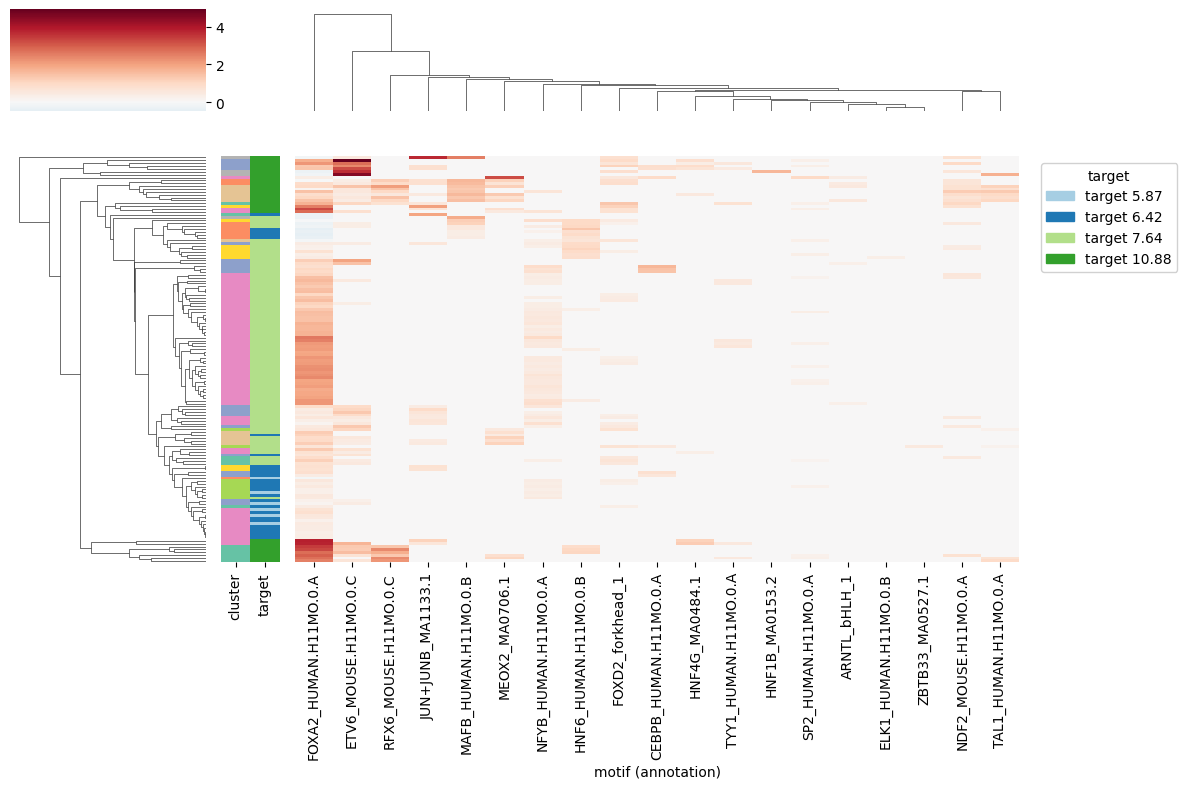

In [118]:
# =========================
# Matrix to plot
# =========================
cols_to_drop = [c for c in ["cluster", "total_delta_attribution", "label", "run", "target"]
                if c in design_motif.columns]
M = design_motif.drop(columns=cols_to_drop)

# Parse run/target/cluster
id_index   = M.index.to_series()
run_ser    = id_index.str.extract(r"run-(\d+)")[0].astype("Int64")
target_ser = id_index.str.extract(r"target-([\d\.]+)(?:_.*)?")[0].astype(float)
cluster_ser = design_motif.loc[M.index, "cluster"]

# =========================
# Build palettes & color strips
# =========================
row_colors = {}

# Cluster strip (no legend needed)
clus_levels = sorted(cluster_ser.unique())
clus_palette = sns.color_palette("Set2", n_colors=len(clus_levels))
clus_lut = dict(zip(clus_levels, clus_palette))
row_colors["cluster"] = cluster_ser.map(lambda c: mpl.colors.to_hex(clus_lut[c]))

# Run strip (no legend needed)
if INCLUDE_RUN:
    run_levels = sorted(run_ser.dropna().unique())
    run_palette = sns.color_palette("tab20", n_colors=len(run_levels))
    run_lut = dict(zip(run_levels, run_palette))
    row_colors["run"] = run_ser.map(lambda x: mpl.colors.to_hex(run_lut[x]) if pd.notna(x) else "#d9d9d9")

# Target strip (categorical legend)
if INCLUDE_TARGET:
    targ_levels = sorted(target_ser.dropna().unique())
    targ_palette = sns.color_palette("Paired", n_colors=len(targ_levels))
    targ_lut = dict(zip(targ_levels, targ_palette))
    row_colors["target"] = target_ser.map(lambda x: mpl.colors.to_hex(targ_lut[x]) if pd.notna(x) else "#d9d9d9")

row_colors_df = pd.DataFrame(row_colors, index=M.index)

# =========================
# Plot clustermap
# =========================
g = sns.clustermap(
    M,
    row_colors=row_colors_df,
    cmap="RdBu_r", center=0,
    figsize=PLOT_FIGSIZE,
    yticklabels=False   # no row ticklabels
)

ax_leg = g.ax_heatmap

# =========================
# Only target legend on the right
# =========================
if INCLUDE_TARGET:
    handles = [mpl.patches.Patch(color=mpl.colors.to_hex(col), label=f"target {lvl}")
               for lvl, col in targ_lut.items()]
    leg = ax_leg.legend(handles=handles, title="target",
                        loc="upper left", bbox_to_anchor=(1.02, 1.0), frameon=True)
    leg.get_frame().set_alpha(0.9)

# Cleanup labels
g.ax_heatmap.set_ylabel("")
g.ax_heatmap.set_xlabel("motif (annotation)")
g.fig.tight_layout()

# Save figure
fig_path = os.path.join(path_out, f"clustermap_dist{DIST_THRESHOLD:.2f}_filt{FILT}.png")
plt.savefig(fig_path, dpi=300)
print(f"Saved clustermap → {fig_path}")

# Identify recurring seqlets

In [121]:
filtered_seqlets_df = seqlets_df[seqlets_df["id"].isin(collapsed_df["id"])]
filtered_seqlets_df = filtered_seqlets_df[filtered_seqlets_df["type"].isin(["addition", "increase"])]
filtered_seqlets_df

,id,start,end,attribution,p-value,attribution_proportion,delta_attribution,type,annotation
32,ISL1_chr5:51392398-51392614_ISM_run-10_target-...,1009,1032,0.995798,0.041181,0.149801,0.485733,increase,FOXA2_HUMAN.H11MO.0.A
33,ISL1_chr5:51392398-51392614_ISM_run-10_target-...,1026,1040,0.428250,0.035744,0.064423,0.428250,addition,ETV6_MOUSE.H11MO.0.C
34,ISL1_chr5:51392398-51392614_ISM_run-10_target-...,1053,1067,0.321316,0.035428,0.048337,0.321316,addition,HNF4G_MA0484.1
35,ISL1_chr5:51392398-51392614_ISM_run-10_target-...,1070,1090,0.646368,0.029900,0.097235,0.264726,increase,FOXA2_HUMAN.H11MO.0.A
71,ISL1_chr5:51392398-51392614_ISM_run-12_target-...,986,1000,0.364482,0.041914,0.054943,0.364482,addition,FOXD2_forkhead_1
...,...,...,...,...,...,...,...,...,...
3553,ISL1_chr5:51392398-51392614_Ledidi_run-9_targe...,980,1002,1.079828,0.033027,0.110604,1.079828,addition,HNF6_HUMAN.H11MO.0.B
3554,ISL1_chr5:51392398-51392614_Ledidi_run-9_targe...,994,1018,1.207940,0.019182,0.123726,1.207940,addition,FOXA2_HUMAN.H11MO.0.A
3555,ISL1_chr5:51392398-51392614_Ledidi_run-9_targe...,1009,1031,1.308043,0.045206,0.133980,0.904990,increase,FOXA2_HUMAN.H11MO.0.A
3556,ISL1_chr5:51392398-51392614_Ledidi_run-9_targe...,1021,1047,1.530698,0.040637,0.156786,1.530698,addition,ETV6_MOUSE.H11MO.0.C


In [122]:
import pandas as pd

def overlap_fraction(a_start, a_end, b_start, b_end):
    """Compute fraction of overlap relative to the shorter interval."""
    ov = max(0, min(a_end, b_end) - max(a_start, b_start))
    short_len = min(a_end - a_start, b_end - b_start)
    return ov / short_len if short_len > 0 else 0

def merge_seqlets_fraction(df, min_fraction: float = 0.5):
    """
    Merge seqlets grouped by annotation, enforcing a minimum fractional overlap.
    
    Parameters
    ----------
    df : pd.DataFrame
        Must have columns ["annotation", "start", "end"].
    min_fraction : float
        Minimum fractional overlap (0–1) of the shorter interval required to merge.
    
    Returns
    -------
    spans_df : pd.DataFrame
        Columns: ["annotation", "span_start", "span_end", "n_seqlets"]
    """
    merged_spans = []
    
    for ann, group in df.groupby("annotation"):
        group = group.sort_values("start")
        
        current_start, current_end = None, None
        n_seqlets = 0
        
        for _, row in group.iterrows():
            s, e = row["start"], row["end"]
            
            if current_start is None:
                current_start, current_end = s, e
                n_seqlets = 1
            else:
                frac = overlap_fraction(current_start, current_end, s, e)
                if frac >= min_fraction:
                    # merge
                    current_start = min(current_start, s)
                    current_end = max(current_end, e)
                    n_seqlets += 1
                else:
                    # no merge → finalize previous span
                    merged_spans.append([ann, current_start, current_end, n_seqlets])
                    current_start, current_end = s, e
                    n_seqlets = 1
        
        if current_start is not None:
            merged_spans.append([ann, current_start, current_end, n_seqlets])
    
    return pd.DataFrame(
        merged_spans,
        columns=["annotation", "span_start", "span_end", "n_seqlets"]
    )

In [124]:
span_df = merge_seqlets_fraction(filtered_seqlets_df, min_fraction=0.8)
span_df["span_length"] = span_df["span_end"] - span_df["span_start"]
span_df.to_csv(os.path.join(path_out, "merged_seqlet_spans.tsv"), sep="\t", index=False)

In [53]:
filtered_seqlets_df.to_csv("/cellar/users/aklie/projects/igvf/sc-islet-design/scratch/2025_09_25/filtered_seqlets.tsv", sep="\t", index=False)

In [79]:
filtered_edit_df = edit_df[edit_df["id"].isin(filtered_seqlets_df["id"])]
filtered_edit_df

,id,chrom,pos,ref,alt,variant_id,relative_pos,dist_to_nearest_exon,nearest_exon_gene
108,ISL1_chr5:51392398-51392614_ISM_run-5_target-6...,chr5,51392428,C,G,chr5:51392428:C:G,982,987,ISL1
109,ISL1_chr5:51392398-51392614_ISM_run-5_target-6...,chr5,51392457,T,A,chr5:51392457:T:A,1011,1016,ISL1
110,ISL1_chr5:51392398-51392614_ISM_run-6_target-6...,chr5,51392434,A,G,chr5:51392434:A:G,988,993,ISL1
111,ISL1_chr5:51392398-51392614_ISM_run-6_target-6...,chr5,51392447,G,T,chr5:51392447:G:T,1001,1006,ISL1
120,ISL1_chr5:51392398-51392614_ISM_run-11_target-...,chr5,51392503,A,C,chr5:51392503:A:C,1057,991,ISL1
...,...,...,...,...,...,...,...,...,...
2183,ISL1_chr5:51392398-51392614_ISM_run-97_target-...,chr5,51392477,T,A,chr5:51392477:T:A,1031,1017,ISL1
2184,ISL1_chr5:51392398-51392614_ISM_run-97_target-...,chr5,51392492,A,C,chr5:51392492:A:C,1046,1002,ISL1
2185,ISL1_chr5:51392398-51392614_ISM_run-97_target-...,chr5,51392495,T,G,chr5:51392495:T:G,1049,999,ISL1
2186,ISL1_chr5:51392398-51392614_ISM_run-97_target-...,chr5,51392542,G,A,chr5:51392542:G:A,1096,952,ISL1


In [51]:
filtered_edit_df["relative_pos"].value_counts()

976     20
1001    15
964     13
960     13
1036    13
962     12
971     12
986     12
996     12
945     12
1097    11
1085    10
1027    10
944     10
967      9
1047     9
1017     8
1016     8
946      8
1022     8
1087     7
997      6
1002     6
950      6
1096     6
973      5
1075     5
935      4
1076     4
1086     4
1098     4
929      3
947      3
943      3
1067     3
1070     3
991      2
1011     2
1042     2
1084     2
1028     1
1029     1
1064     1
1035     1
998      1
1037     1
977      1
988      1
1116     1
Name: relative_pos, dtype: int64